# Level 3 Second Term Project

## Machine Learning GitHub Repository Analysis

**Student Name:** Mazen  
**Student ID:** DECI4-S-416558  
**Date:** 22 August 2026

### Project Overview
This project collects public GitHub repository data about machine learning, cleans the data with Pandas, stores it in SQLite, analyzes it with SQL, and creates simple charts with Matplotlib.

## Task 1 - Data Collection and Preparation

### 1. Import Libraries

In [ ]:
import requests
import pandas as pd

### 2. Collect Repository Data from the GitHub API

In [ ]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

response = requests.get(url)
print("Status code:", response.status_code)

data = response.json()
print("Repositories received:", len(data["items"]))

Status code: 200
Repositories received: 100


The API request returns the repository data in JSON format. The next step is to place the repository records into a Pandas DataFrame.

### 3. Create and Explore the DataFrame

In [ ]:
df = pd.DataFrame(data["items"])
df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76098,2930,197323,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34324,2395,164339,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,22035,13,89682,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15272,52,82599,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15618,26,74116,master,1.0


In [ ]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 100
Columns: 82


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

### 4. Select the Required Columns

In [ ]:
required_columns = [
    "name",
    "owner",
    "language",
    "stargazers_count",
    "forks_count",
    "watchers_count",
    "open_issues_count",
    "created_at",
    "updated_at",
    "license"
]

df = df[required_columns]
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,197323,76098,197323,2930,2015-11-07T01:19:20Z,2026-08-22T18:21:22Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164339,34324,164339,2395,2018-10-29T13:56:00Z,2026-08-22T18:16:07Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89682,22035,89682,13,2021-03-03T01:34:05Z,2026-08-22T17:59:10Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82599,15272,82599,52,2018-08-21T11:20:39Z,2026-08-22T17:48:46Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74116,15618,74116,26,2014-07-15T19:11:19Z,2026-08-22T18:27:41Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


### 5. Extract Values from Nested Columns

In [ ]:
df["owner"] = df["owner"].apply(lambda x: x.get("login") if isinstance(x, dict) else None)
df["license"] = df["license"].apply(lambda x: x.get("name") if isinstance(x, dict) else None)

df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow,C++,197323,76098,197323,2930,2015-11-07T01:19:20Z,2026-08-22T18:21:22Z,Apache License 2.0
1,transformers,huggingface,Python,164339,34324,164339,2395,2018-10-29T13:56:00Z,2026-08-22T18:16:07Z,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89682,22035,89682,13,2021-03-03T01:34:05Z,2026-08-22T17:59:10Z,MIT License
3,funNLP,fighting41love,Python,82599,15272,82599,52,2018-08-21T11:20:39Z,2026-08-22T17:48:46Z,None
4,awesome-machine-learning,josephmisiti,Python,74116,15618,74116,26,2014-07-15T19:11:19Z,2026-08-22T18:27:41Z,Other


### 6. Check and Handle Missing Values

In [ ]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
name                  0
owner                 0
language             23
stargazers_count      0
forks_count           0
watchers_count        0
open_issues_count     0
created_at            0
updated_at            0
license              22
dtype: int64


In [ ]:
df["language"] = df["language"].fillna("Unknown")
df["license"] = df["license"].fillna("Unknown")

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
name                 0
owner                0
language             0
stargazers_count     0
forks_count          0
watchers_count       0
open_issues_count    0
created_at           0
updated_at           0
license              0
dtype: int64


### 7. Check and Remove Duplicate Records

In [ ]:
print("Duplicate rows before cleaning:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0


### 8. Prepare the Date Columns and Rename Columns

In [ ]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

df = df.rename(columns={
    "stargazers_count": "stars",
    "forks_count": "forks",
    "watchers_count": "watchers",
    "open_issues_count": "open_issues",
    "created_at": "created_date",
    "updated_at": "updated_date"
})

df.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197323,76098,197323,2930,2015-11-07 01:19:20+00:00,2026-08-22 18:21:22+00:00,Apache License 2.0
1,transformers,huggingface,Python,164339,34324,164339,2395,2018-10-29 13:56:00+00:00,2026-08-22 18:16:07+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89682,22035,89682,13,2021-03-03 01:34:05+00:00,2026-08-22 17:59:10+00:00,MIT License
3,funNLP,fighting41love,Python,82599,15272,82599,52,2018-08-21 11:20:39+00:00,2026-08-22 17:48:46+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74116,15618,74116,26,2014-07-15 19:11:19+00:00,2026-08-22 18:27:41+00:00,Other


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   name          100 non-null    object             
 1   owner         100 non-null    object             
 2   language      100 non-null    object             
 3   stars         100 non-null    int64              
 4   forks         100 non-null    int64              
 5   watchers      100 non-null    int64              
 6   open_issues   100 non-null    int64              
 7   created_date  100 non-null    datetime64[ns, UTC]
 8   updated_date  100 non-null    datetime64[ns, UTC]
 9   license       100 non-null    object             
dtypes: datetime64[ns, UTC](2), int64(4), object(4)
memory usage: 7.9+ KB


### 9. Save and Verify the Cleaned Dataset

In [ ]:
df.to_csv("github_projects.csv", index=False)
print("Saved github_projects.csv")

Saved github_projects.csv


In [ ]:
check_df = pd.read_csv("github_projects.csv")
print("Rows in saved file:", len(check_df))
print("Columns in saved file:", list(check_df.columns))
check_df.head()

Rows in saved file: 100
Columns in saved file: ['name', 'owner', 'language', 'stars', 'forks', 'watchers', 'open_issues', 'created_date', 'updated_date', 'license']


,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197323,76098,197323,2930,2015-11-07 01:19:20+00:00,2026-08-22 18:21:22+00:00,Apache License 2.0
1,transformers,huggingface,Python,164339,34324,164339,2395,2018-10-29 13:56:00+00:00,2026-08-22 18:16:07+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89682,22035,89682,13,2021-03-03 01:34:05+00:00,2026-08-22 17:59:10+00:00,MIT License
3,funNLP,fighting41love,Python,82599,15272,82599,52,2018-08-21 11:20:39+00:00,2026-08-22 17:48:46+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74116,15618,74116,26,2014-07-15 19:11:19+00:00,2026-08-22 18:27:41+00:00,Other


## Task 2 - Store and Analyse the Data

### 1. Create the SQLite Database

In [ ]:
import sqlite3

conn = sqlite3.connect("github_projects.db")
df = pd.read_csv("github_projects.csv")
df.to_sql("Repositories", conn, if_exists="replace", index=False)

pd.read_sql("SELECT * FROM Repositories LIMIT 5", conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197323,76098,197323,2930,2015-11-07 01:19:20+00:00,2026-08-22 18:21:22+00:00,Apache License 2.0
1,transformers,huggingface,Python,164339,34324,164339,2395,2018-10-29 13:56:00+00:00,2026-08-22 18:16:07+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89682,22035,89682,13,2021-03-03 01:34:05+00:00,2026-08-22 17:59:10+00:00,MIT License
3,funNLP,fighting41love,Python,82599,15272,82599,52,2018-08-21 11:20:39+00:00,2026-08-22 17:48:46+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74116,15618,74116,26,2014-07-15 19:11:19+00:00,2026-08-22 18:27:41+00:00,Other


### 2. Filtering and Searching

In [ ]:
query = """
SELECT *
FROM Repositories
WHERE stars > 10000;
"""
pd.read_sql(query, conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197323,76098,197323,2930,2015-11-07 01:19:20+00:00,2026-08-22 18:21:22+00:00,Apache License 2.0
1,transformers,huggingface,Python,164339,34324,164339,2395,2018-10-29 13:56:00+00:00,2026-08-22 18:16:07+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89682,22035,89682,13,2021-03-03 01:34:05+00:00,2026-08-22 17:59:10+00:00,MIT License
3,funNLP,fighting41love,Python,82599,15272,82599,52,2018-08-21 11:20:39+00:00,2026-08-22 17:48:46+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74116,15618,74116,26,2014-07-15 19:11:19+00:00,2026-08-22 18:27:41+00:00,Other
...,...,...,...,...,...,...,...,...,...,...
65,machine-learning-systems-design,chiphuyen,HTML,10538,1631,10538,11,2019-11-24 23:16:28+00:00,2026-08-22 15:50:24+00:00,Unknown
66,Machine-Learning,Jack-Cherish,Python,10372,5065,10372,7,2017-03-25 07:32:37+00:00,2026-08-22 15:54:58+00:00,Unknown
67,machine-learning-notes,roboticcam,Jupyter Notebook,10337,1825,10337,28,2018-02-15 15:42:33+00:00,2026-08-21 07:52:17+00:00,Unknown
68,3D-Machine-Learning,timzhang642,Unknown,10191,1797,10191,21,2017-08-12 15:20:54+00:00,2026-08-21 09:19:46+00:00,Unknown


In [ ]:
query = """
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%';
"""
pd.read_sql(query, conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,awesome-machine-learning,josephmisiti,Python,74116,15618,74116,26,2014-07-15 19:11:19+00:00,2026-08-22 18:27:41+00:00,Other
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36454,7454,36454,68,2021-01-02 12:08:37+00:00,2026-08-22 16:09:36+00:00,Unknown
2,machine-learning-for-software-engineers,ZuzooVn,Unknown,28867,6146,28867,32,2016-10-09 21:20:25+00:00,2026-08-22 13:13:25+00:00,Creative Commons Attribution Share Alike 4.0 I...
3,homemade-machine-learning,trekhleb,Jupyter Notebook,24773,4193,24773,30,2018-11-01 04:34:19+00:00,2026-08-22 13:09:31+00:00,MIT License
4,awesome-production-machine-learning,EthicalML,Unknown,20860,2590,20860,31,2018-08-15 14:28:41+00:00,2026-08-22 16:14:33+00:00,MIT License
5,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20576,5550,20576,6,2018-05-09 12:33:08+00:00,2026-08-22 17:47:31+00:00,MIT License
6,stanford-cs-229-machine-learning,afshinea,Unknown,20142,4251,20142,20,2018-08-04 23:01:00+00:00,2026-08-22 16:43:11+00:00,MIT License
7,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18130,3968,18130,47,2015-09-12 14:51:38+00:00,2026-08-22 14:20:39+00:00,Creative Commons Zero v1.0 Universal
8,machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,13987,3102,13987,3,2020-04-17 04:29:23+00:00,2026-08-22 17:44:43+00:00,Unknown
9,machine-learning-interview,khangich,Unknown,12789,2044,12789,9,2020-08-11 06:26:32+00:00,2026-08-21 20:32:51+00:00,Unknown


### 3. Logical Operators: AND, OR, NOT

In [ ]:
query = """
SELECT name, stars, forks
FROM Repositories
WHERE stars > 1000
AND forks > 100;
"""
pd.read_sql(query, conn)

,name,stars,forks
0,tensorflow,197323,76098
1,transformers,164339,34324
2,ML-For-Beginners,89682,22035
3,funNLP,82599,15272
4,awesome-machine-learning,74116,15618
...,...,...,...
95,Machine-learning-learning-notes,7761,1879
96,awesome-youtubers,7740,498
97,Learn_Machine_Learning_in_3_Months,7603,2311
98,h2o-3,7495,2025


In [ ]:
query = """
SELECT name, language, stars
FROM Repositories
WHERE language = 'Python'
OR language = 'C++';
"""
pd.read_sql(query, conn)

,name,language,stars
0,tensorflow,C++,197323
1,transformers,Python,164339
2,funNLP,Python,82599
3,awesome-machine-learning,Python,74116
4,scikit-learn,Python,67010
5,gradio,Python,43405
6,C-Plus-Plus,C++,34591
7,ML-From-Scratch,Python,32506
8,linkedin-skill-assessments-quizzes,Python,28804
9,cs249r_book,Python,27978


In [ ]:
query = """
SELECT name, language, stars
FROM Repositories
WHERE NOT language = 'Python';
"""
pd.read_sql(query, conn)

,name,language,stars
0,tensorflow,C++,197323
1,ML-For-Beginners,Jupyter Notebook,89682
2,500-AI-Machine-learning-Deep-learning-Computer...,Unknown,36454
3,C-Plus-Plus,C++,34591
4,netron,JavaScript,33387
...,...,...,...
65,Machine-learning-learning-notes,Unknown,7761
66,awesome-youtubers,Markdown,7740
67,Learn_Machine_Learning_in_3_Months,Unknown,7603
68,h2o-3,Jupyter Notebook,7495


### 4. Sorting and Top 10 Repositories

In [ ]:
query = """
SELECT name, stars
FROM Repositories
ORDER BY stars DESC;
"""
pd.read_sql(query, conn)

,name,stars
0,tensorflow,197323
1,transformers,164339
2,ML-For-Beginners,89682
3,funNLP,82599
4,awesome-machine-learning,74116
...,...,...
95,Machine-learning-learning-notes,7761
96,awesome-youtubers,7740
97,Learn_Machine_Learning_in_3_Months,7603
98,h2o-3,7495


In [ ]:
query = """
SELECT name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""
top10 = pd.read_sql(query, conn)
top10

,name,stars
0,tensorflow,197323
1,transformers,164339
2,ML-For-Beginners,89682
3,funNLP,82599
4,awesome-machine-learning,74116
5,scikit-learn,67010
6,gradio,43405
7,500-AI-Machine-learning-Deep-learning-Computer...,36454
8,C-Plus-Plus,34591
9,netron,33387


### 5. Aggregate Functions

In [ ]:
query = """
SELECT COUNT(*) AS total_repositories
FROM Repositories;
"""
pd.read_sql(query, conn)

,total_repositories
0,100


In [ ]:
query = """
SELECT AVG(stars) AS average_stars
FROM Repositories;
"""
pd.read_sql(query, conn)

,average_stars
0,20821.82


### 6. Grouping Analysis

In [ ]:
query = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC;
"""
language_groups = pd.read_sql(query, conn)
language_groups

,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


### 7. Create Visualizations

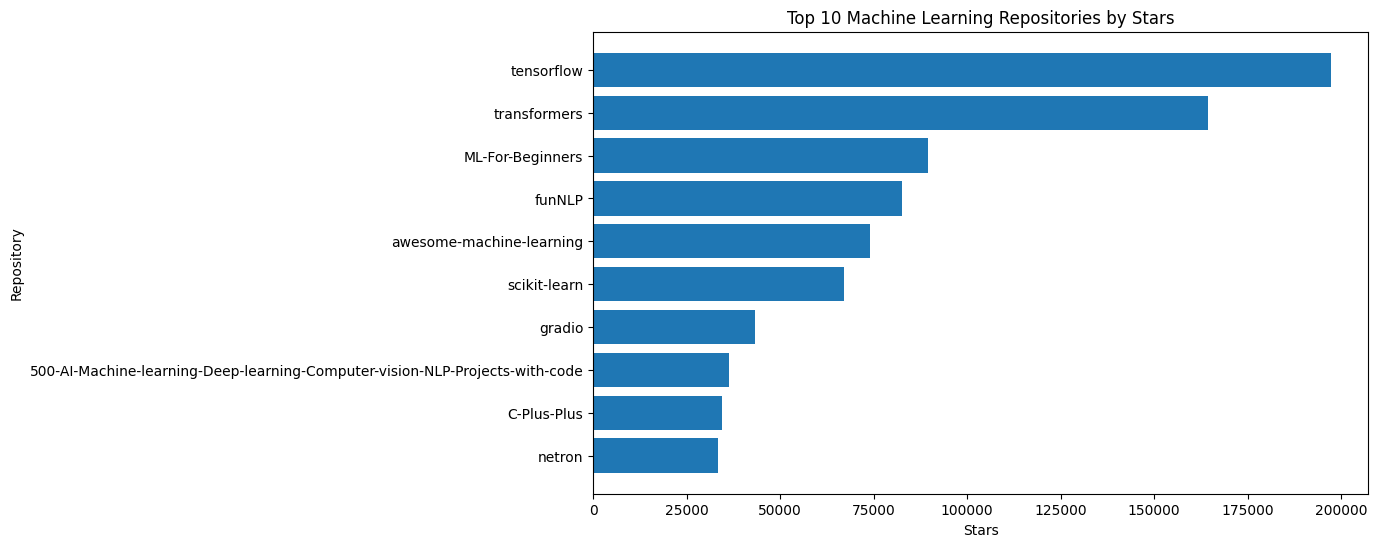

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top10["name"], top10["stars"])
plt.xlabel("Stars")
plt.ylabel("Repository")
plt.title("Top 10 Machine Learning Repositories by Stars")
plt.gca().invert_yaxis()
plt.show()

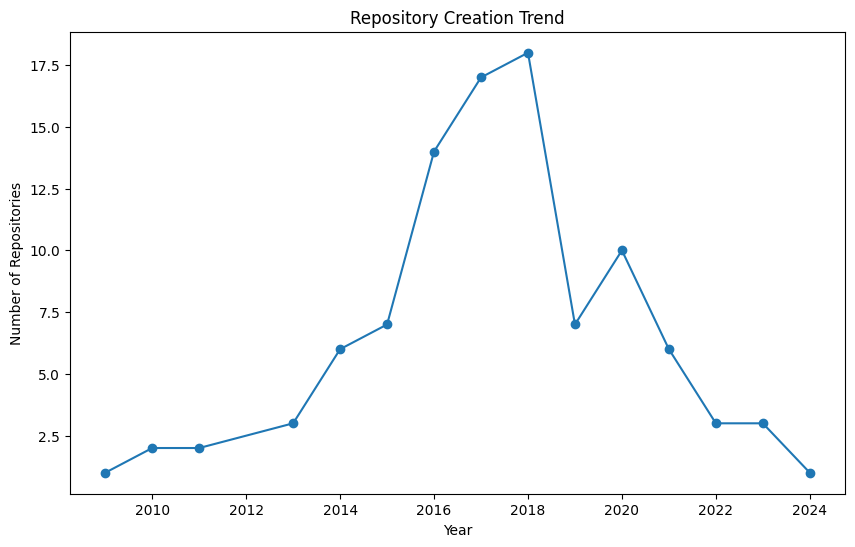

In [ ]:
df["created_date"] = pd.to_datetime(df["created_date"])
yearly = df.groupby(df["created_date"].dt.year).size()

plt.figure(figsize=(10, 6))
plt.plot(yearly.index, yearly.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Repositories")
plt.title("Repository Creation Trend")
plt.show()

### 8. Results and Findings

1. **Repository Popularity:** A small group of leading repositories (such as TensorFlow and Transformers) have significantly higher star counts than the rest of the dataset, showing that open-source ML activity centers around major foundational frameworks.
2. **Language Distribution:** Python is the most dominant programming language across the dataset, followed by C++ and Jupyter Notebooks. C++ repositories have high star averages because they power the underlying high-performance engines of deep learning tools.
3. **Creation Trends:** Repository creation increased noticeably from 2015 onwards, reflecting the growth of modern deep learning and recent generative AI tooling.

## Task 3 - Git, GitHub, and Ethics

### GitHub Repository

**GitHub Repository:** [https://github.com/11Mazen22/LV3-SecondTermProject](https://github.com/11Mazen22/LV3-SecondTermProject)

## Ethics Reflection

### Question 1: Why is it important to verify data collected from public APIs?

It is important to verify API data because it can contain missing, incorrect, or unexpected values. Checking the data helps make sure that the analysis uses reliable information.

### Question 2: Why should data analysts document the source of their data?

Data analysts should document the source so other people can see where the data came from and check it when needed. It also makes the analysis easier to understand and repeat.

### Question 3: How can missing or inaccurate data affect data analysis and decision-making?

Missing or inaccurate data can change calculations and charts and may lead to wrong conclusions. Cleaning and checking the data before analysis helps reduce this problem.